<a href="https://colab.research.google.com/github/rwalden-gif/IntroToML/blob/main/Homework2_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = 'https://raw.githubusercontent.com/rwalden-gif/IntroToML/main/Housing.csv'
df = pd.read_csv(url)

binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

np.random.seed(42)
shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)
split_idx = int(0.8 * len(shuffled_df))

train_df = shuffled_df.iloc[:split_idx]
test_df = shuffled_df.iloc[split_idx:]

features_a = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
features_b = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
              'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
              'parking', 'prefarea']

X_tr_a, X_te_a = train_df[features_a].values, test_df[features_a].values
X_tr_b, X_te_b = train_df[features_b].values, test_df[features_b].values
y_tr, y_te = train_df['price'].values, test_df['price'].values

def standardize(X_tr, X_te):
    mean, std = np.mean(X_tr, axis=0), np.std(X_tr, axis=0)
    return (X_tr - mean) / std, (X_te - mean) / std

def normalize(X_tr, X_te):
    x_min, x_max = np.min(X_tr, axis=0), np.max(X_tr, axis=0)
    return (X_tr - x_min) / (x_max - x_min), (X_te - x_min) / (x_max - x_min)

X_tr_a_std, X_te_a_std = standardize(X_tr_a, X_te_a)
X_tr_a_norm, X_te_a_norm = normalize(X_tr_a, X_te_a)

X_tr_b_std, X_te_b_std = standardize(X_tr_b, X_te_b)
X_tr_b_norm, X_te_b_norm = normalize(X_tr_b, X_te_b)

In [2]:
def gradient_descent(X_train, y_train, X_test, y_test, alpha, iterations, lam=0):
    m_tr, m_te = len(y_train), len(y_test)

    X_tr = np.c_[np.ones(m_tr), X_train]
    X_te = np.c_[np.ones(m_te), X_test]

    theta = np.zeros(X_tr.shape[1])
    train_losses, val_losses = [], []

    for _ in range(iterations):
        errors = X_tr.dot(theta) - y_train
        gradient = (1 / m_tr) * X_tr.T.dot(errors)

        if lam > 0:
            reg_penalty = (lam / m_tr) * theta
            reg_penalty[0] = 0
            gradient += reg_penalty

        theta -= alpha * gradient

        # Loss J(theta) = 1/(2m) * sum((h(x) - y)^2)
        train_loss = (1 / (2 * m_tr)) * np.sum((X_tr.dot(theta) - y_train) ** 2)
        val_loss = (1 / (2 * m_te)) * np.sum((X_te.dot(theta) - y_test) ** 2)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return theta, train_losses, val_losses

def plot_loss(train_loss, val_loss, title):
    plt.figure(figsize=(6, 4))
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.xlabel('Iterations')
    plt.ylabel('Loss (MSE / 2)')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

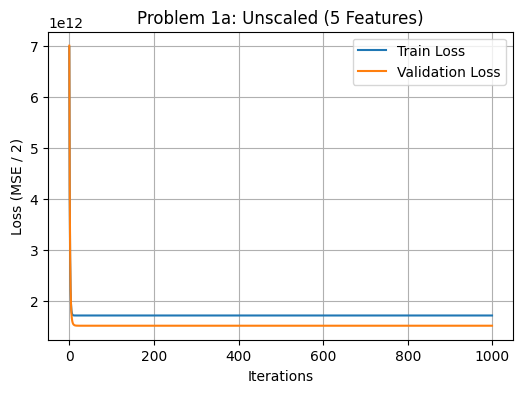

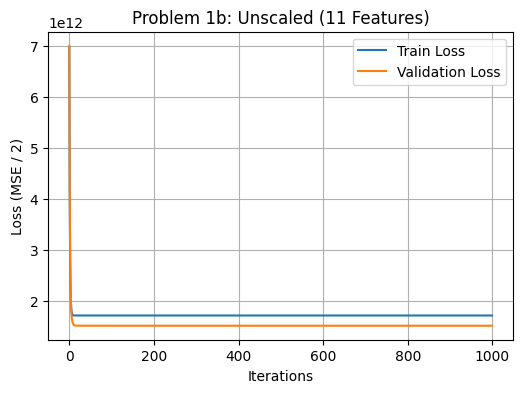

In [3]:
iters = 1000

# Problem 1: Unscaled Data
theta_1a, tr_1a, val_1a = gradient_descent(X_tr_a, y_tr, X_te_a, y_te, alpha=1e-8, iterations=iters)
plot_loss(tr_1a, val_1a, "Problem 1a: Unscaled (5 Features)")

theta_1b, tr_1b, val_1b = gradient_descent(X_tr_b, y_tr, X_te_b, y_te, alpha=1e-8, iterations=iters)
plot_loss(tr_1b, val_1b, "Problem 1b: Unscaled (11 Features)")

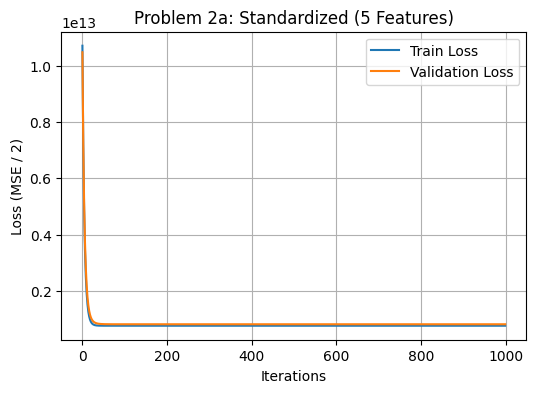

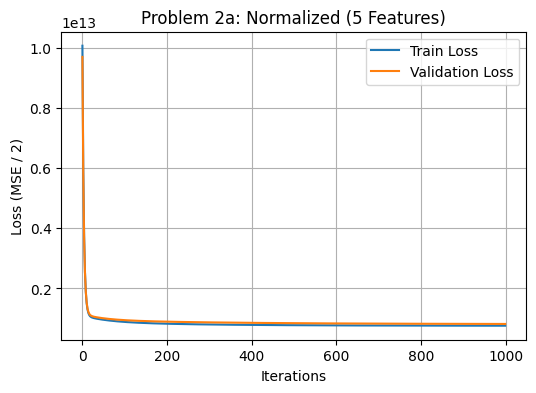

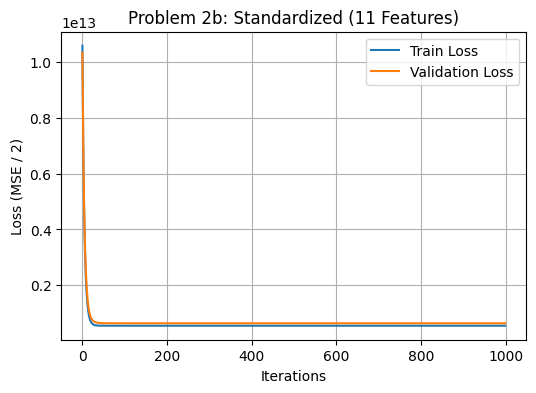

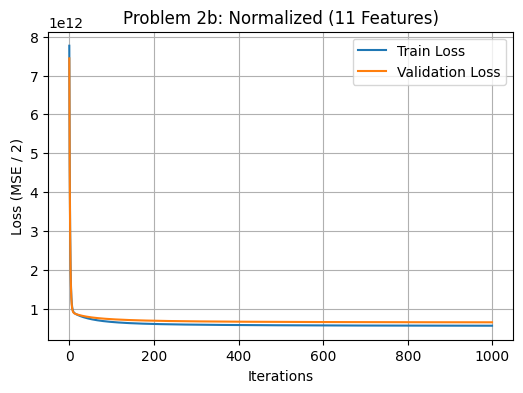

In [4]:
# Problem 2: Scaled Data
_, tr_2a_std, val_2a_std = gradient_descent(X_tr_a_std, y_tr, X_te_a_std, y_te, alpha=0.1, iterations=iters)
_, tr_2a_norm, val_2a_norm = gradient_descent(X_tr_a_norm, y_tr, X_te_a_norm, y_te, alpha=0.1, iterations=iters)
plot_loss(tr_2a_std, val_2a_std, "Problem 2a: Standardized (5 Features)")
plot_loss(tr_2a_norm, val_2a_norm, "Problem 2a: Normalized (5 Features)")

_, tr_2b_std, val_2b_std = gradient_descent(X_tr_b_std, y_tr, X_te_b_std, y_te, alpha=0.1, iterations=iters)
_, tr_2b_norm, val_2b_norm = gradient_descent(X_tr_b_norm, y_tr, X_te_b_norm, y_te, alpha=0.1, iterations=iters)
plot_loss(tr_2b_std, val_2b_std, "Problem 2b: Standardized (11 Features)")
plot_loss(tr_2b_norm, val_2b_norm, "Problem 2b: Normalized (11 Features)")

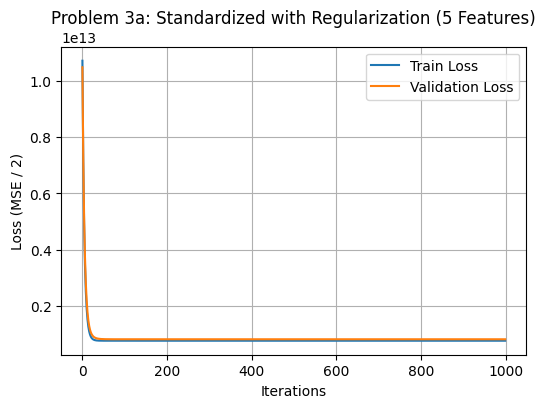

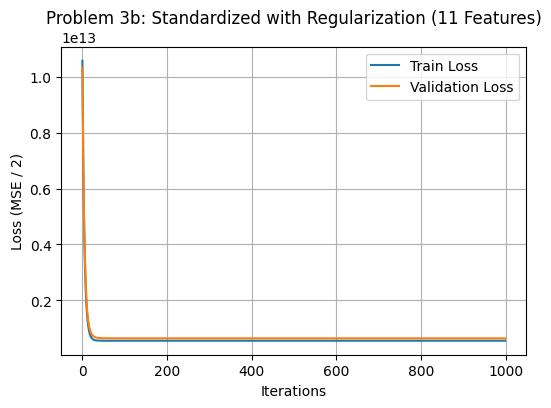

In [5]:
# Problem 3: Regularization
theta_3a, tr_3a, val_3a = gradient_descent(X_tr_a_std, y_tr, X_te_a_std, y_te, alpha=0.1, iterations=iters, lam=10)
plot_loss(tr_3a, val_3a, "Problem 3a: Standardized with Regularization (5 Features)")

theta_3b, tr_3b, val_3b = gradient_descent(X_tr_b_std, y_tr, X_te_b_std, y_te, alpha=0.1, iterations=iters, lam=10)
plot_loss(tr_3b, val_3b, "Problem 3b: Standardized with Regularization (11 Features)")